# ????? ?? ?? ??

?? ??? CS ??(WISMO ??)? ??? ??? ?????, ?????? ?? ?? ??? ?? ?? ??? ????.

**?? ???:**
1. ??? ?? ???? ??
2. ????? ?? ?? WISMO ?? ??
3. ?? ?? WISMO ???
   - ???: Logistic Regression
   - ??? ?????: XGBoost
4. ?? ???? ?? ?? ?? ??? ? 1? ?? ?? ??
5. ?? ???? 1? ?? ? ?? CS ?? ? LTV ?? ?? ??


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")


D:\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1. 데이터 로드

In [2]:
from pathlib import Path

data_dir_candidates = [
    Path('../data'),
    Path(r'C:/Users/GAZI/Desktop/A_Proj/Olist/Olist_b/data'),
]
DATA_DIR = next((candidate for candidate in data_dir_candidates if (candidate / 'merged_olist.csv').exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('merged_olist.csv not found')

risk_sellers = pd.read_csv(DATA_DIR / 'risk_report_result.csv')
merged_df = pd.read_csv(DATA_DIR / 'merged_olist.csv')


## 2. 판매자 배송 지연 산출

In [3]:
# ?? ?? ??
merged_df['order_delivered_carrier_date'] = pd.to_datetime(merged_df['order_delivered_carrier_date'], errors='coerce')
merged_df['shipping_limit_date'] = pd.to_datetime(merged_df['shipping_limit_date'], errors='coerce')

merged_df['delay_days'] = (
    (merged_df['order_delivered_carrier_date'] - merged_df['shipping_limit_date']).dt.total_seconds()
    / (24 * 3600)
).clip(lower=0)

ship_data = merged_df[['order_id', 'seller_id', 'delay_days']].dropna(subset=['delay_days']).copy()

print(f"  - ?? ???: {len(ship_data):,}?")
print(f"  - ?? ?? ??: {ship_data['delay_days'].mean():.2f}?")


  - ?? ???: 64,850?
  - ?? ?? ??: 0.23?


## 3. WISMO 티켓 식별

포르투갈어 리뷰 텍스트에서 배송 문의(WISMO: Where Is My Order) 키워드를 탐지한다.

In [4]:
# WISMO ??? (?????)
wismo_keywords = [
    'n?o recebi',
    'cad?',
    'entrega',
    'atraso',
    'chegou',
    'ainda n?o',
    'onde est?'
]
wismo_pattern = '|'.join(wismo_keywords)

merged_df['review_comment_message'] = merged_df['review_comment_message'].fillna('')
merged_df['is_wismo'] = merged_df['review_comment_message'].str.contains(
    wismo_pattern,
    case=False,
    na=False,
    regex=True
).astype(int)

wismo_count = merged_df['is_wismo'].sum()
wismo_rate = (wismo_count / len(merged_df)) * 100

print(f"  - ?? ???: {len(merged_df):,}?")
print(f"  - WISMO ??: {wismo_count:,}? ({wismo_rate:.2f}%)")

final_df = merged_df[['order_id', 'seller_id', 'delay_days', 'is_wismo']].dropna(subset=['delay_days']).copy()
print(f"  - ???? ???: {len(final_df):,}?")


  - ?? ???: 64,850?
  - WISMO ??: 12,138? (18.72%)
  - ???? ???: 64,850?


## 4. ?? ?? WISMO ???

?? ??? ?? ??? ????? ????, ?? ?? ??? ??(Logistic Regression)? ??? ????? ??(XGBoost)? ?? ????.


In [5]:
reg_data = final_df.groupby('delay_days')['is_wismo'].mean().reset_index()
reg_data = reg_data[reg_data['delay_days'] <= 20]

legacy_X = reg_data[['delay_days']]
legacy_y = reg_data['is_wismo']
legacy_model = LinearRegression().fit(legacy_X, legacy_y)

legacy_beta = legacy_model.coef_[0]
legacy_intercept = legacy_model.intercept_
legacy_r_squared = legacy_model.score(legacy_X, legacy_y)

model_df = merged_df.copy()
model_df['review_comment_message'] = model_df['review_comment_message'].fillna('')
model_df['is_wismo'] = model_df['review_comment_message'].str.contains(
    wismo_pattern,
    case=False,
    na=False,
    regex=True
).astype(int)

for col in ['order_delivered_carrier_date', 'shipping_limit_date']:
    model_df[col] = pd.to_datetime(model_df[col], errors='coerce')

model_df['delay_days'] = (
    (model_df['order_delivered_carrier_date'] - model_df['shipping_limit_date']).dt.total_seconds()
    / (24 * 3600)
).clip(lower=0)

ops_num_features = [
    'delay_days', 'seller_delay_days', 'seller_processing_days', 'processing_days_diff',
    'delivery_days', 'pg_processing_days', 'price', 'freight_value', 'product_weight_g',
    'product_length_cm', 'product_height_cm', 'product_width_cm', 'payment_installments',
    'payment_value_total', 'is_black_friday', 'is_carnival', 'is_logistics_fault', 'is_same_state'
]
ops_cat_features = ['product_category_name_english', 'seller_state', 'customer_state', 'payment_types']
explain_num_features = ops_num_features + ['review_score', 'has_text_review']
explain_cat_features = ops_cat_features.copy()

def build_preprocessor(num_features, cat_features):
    return ColumnTransformer(
        transformers=[
            ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
            ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), cat_features),
        ]
    )

def evaluate_prob_model(y_true, y_prob):
    null_prob = np.repeat(y_true.mean(), len(y_true))
    model_nll = log_loss(y_true, y_prob, normalize=False)
    null_nll = log_loss(y_true, null_prob, normalize=False)
    return {
        'roc_auc': roc_auc_score(y_true, y_prob),
        'pr_auc': average_precision_score(y_true, y_prob),
        'log_loss': log_loss(y_true, y_prob),
        'pseudo_r2': 1 - (model_nll / null_nll),
    }

explain_df = model_df[explain_num_features + explain_cat_features + ['is_wismo']].copy()
for col in explain_num_features:
    explain_df[col] = pd.to_numeric(explain_df[col], errors='coerce')
explain_df = explain_df.dropna(subset=['delay_days'])

X_explain = explain_df[explain_num_features + explain_cat_features]
y_explain = explain_df['is_wismo']
X_explain_train, X_explain_test, y_explain_train, y_explain_test = train_test_split(
    X_explain, y_explain, test_size=0.2, random_state=42, stratify=y_explain
)

explain_model = Pipeline(
    steps=[
        ('preprocessor', build_preprocessor(explain_num_features, explain_cat_features)),
        ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced')),
    ]
)
explain_model.fit(X_explain_train, y_explain_train)
explain_test_prob = explain_model.predict_proba(X_explain_test)[:, 1]
explain_metrics = evaluate_prob_model(y_explain_test, explain_test_prob)

ops_df = model_df[['seller_id'] + ops_num_features + ops_cat_features + ['review_score', 'is_wismo']].copy()
for col in ops_num_features + ['review_score']:
    ops_df[col] = pd.to_numeric(ops_df[col], errors='coerce')
ops_df = ops_df.dropna(subset=['delay_days'])

X_ops = ops_df[ops_num_features + ops_cat_features]
y_ops = ops_df['is_wismo']
X_ops_train, X_ops_test, y_ops_train, y_ops_test = train_test_split(
    X_ops, y_ops, test_size=0.2, random_state=42, stratify=y_ops
)

ops_model = Pipeline(
    steps=[
        ('preprocessor', build_preprocessor(ops_num_features, ops_cat_features)),
        ('classifier', XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=4,
        )),
    ]
)
ops_model.fit(X_ops_train, y_ops_train)
ops_test_prob = ops_model.predict_proba(X_ops_test)[:, 1]
ops_metrics = evaluate_prob_model(y_ops_test, ops_test_prob)

print("[???] ??? ?? ??")
print(f"  - Beta: {legacy_beta:.6f}")
print(f"  - Intercept: {legacy_intercept:.6f}")
print(f"  - R?: {legacy_r_squared:.4f}")
print()
print("[???] Logistic Regression")
print(f"  - ROC-AUC: {explain_metrics['roc_auc']:.4f}")
print(f"  - PR-AUC: {explain_metrics['pr_auc']:.4f}")
print(f"  - Log Loss: {explain_metrics['log_loss']:.4f}")
print(f"  - Pseudo R?: {explain_metrics['pseudo_r2']:.4f}")
print()
print("[???] XGBoost")
print(f"  - ROC-AUC: {ops_metrics['roc_auc']:.4f}")
print(f"  - PR-AUC: {ops_metrics['pr_auc']:.4f}")
print(f"  - Log Loss: {ops_metrics['log_loss']:.4f}")
print(f"  - Pseudo R?: {ops_metrics['pseudo_r2']:.4f}")


[???] ??? ?? ??
  - Beta: 0.015603
  - Intercept: 0.171879
  - R?: 0.0173

[???] Logistic Regression
  - ROC-AUC: 0.8840
  - PR-AUC: 0.5469
  - Log Loss: 0.3867
  - Pseudo R?: 0.1979

[???] XGBoost
  - ROC-AUC: 0.5958
  - PR-AUC: 0.2934
  - Log Loss: 0.4688
  - Pseudo R?: 0.0276


## 5. ???? ?? ?? ??

`?? ?? ?? = ?(??? WISMO ????) ? ?? ??($4.60)`

?? `??? ? ?????? ? beta` ??? ????, ?? ?? ????? ????? ????. ?? ?? ????? 1? ??? ?? ??? ???? ?? ????.


In [6]:
cost_per_ticket = 4.6
simulation_delay_features = [
    'delay_days', 'seller_delay_days', 'seller_processing_days', 'processing_days_diff', 'delivery_days'
]

def apply_one_day_reduction(feature_df, delay_features):
    counterfactual = feature_df.copy()
    for col in delay_features:
        counterfactual[col] = counterfactual[col].fillna(0) - 1
        if col != 'processing_days_diff':
            counterfactual[col] = counterfactual[col].clip(lower=0)
    return counterfactual

ops_model_full = Pipeline(
    steps=[
        ('preprocessor', build_preprocessor(ops_num_features, ops_cat_features)),
        ('classifier', XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=4,
        )),
    ]
)
ops_model_full.fit(X_ops, y_ops)

unique_risk_sellers = risk_sellers['seller_id'].unique()
print(f"  - ?? ?? ??? ?: {len(unique_risk_sellers):,}?")

risk_orders = ops_df[ops_df['seller_id'].isin(unique_risk_sellers)].copy()
risk_order_features = risk_orders[ops_num_features + ops_cat_features].copy()
risk_orders['baseline_wismo_prob'] = ops_model_full.predict_proba(risk_order_features)[:, 1]

risk_order_cf_features = apply_one_day_reduction(risk_order_features, simulation_delay_features)
risk_orders['counterfactual_wismo_prob'] = ops_model_full.predict_proba(risk_order_cf_features)[:, 1]
risk_orders['avoided_wismo_prob_1day'] = (
    risk_orders['baseline_wismo_prob'] - risk_orders['counterfactual_wismo_prob']
).clip(lower=0)

seller_damage_df = (
    risk_orders.groupby('seller_id')
    .agg(
        total_orders=('seller_id', 'size'),
        avg_delay_days=('delay_days', 'mean'),
        expected_wismo_tickets=('baseline_wismo_prob', 'sum'),
        avoided_wismo_tickets_1day=('avoided_wismo_prob_1day', 'sum'),
    )
    .reset_index()
)

seller_damage_df['estimated_damage_cost_usd'] = seller_damage_df['expected_wismo_tickets'] * cost_per_ticket
seller_damage_df['avoidable_damage_cost_usd_1day'] = seller_damage_df['avoided_wismo_tickets_1day'] * cost_per_ticket
seller_damage_df = seller_damage_df.sort_values('avoidable_damage_cost_usd_1day', ascending=False).reset_index(drop=True)

print(f"  - ??? ?? ??: {len(seller_damage_df):,}?")
print(f"  - ?? ? WISMO ??(?? ???): {seller_damage_df['expected_wismo_tickets'].sum():,.2f}?")
print(f"  - 1? ?? ? ?? WISMO ??: {seller_damage_df['avoided_wismo_tickets_1day'].sum():,.2f}?")


  - ?? ?? ??? ?: 1,420?


  - ??? ?? ??: 1,420?
  - ?? ? WISMO ??(?? ???): 11,531.80?
  - 1? ?? ? ?? WISMO ??: 1,024.42?


In [7]:
output_file = DATA_DIR / 'seller_damage_cost.csv'
seller_damage_df.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"? ?? ?? ??: {output_file}")


? ?? ?? ??: ..\data\seller_damage_cost.csv


In [8]:
COST_PER_TICKET = 4.60
EXCHANGE_RATE = 1433
BRL_PER_USD = 3.19
KRW_PER_BRL = EXCHANGE_RATE / BRL_PER_USD
LTV_BRL = 180
ANNUAL_TOTAL_ORDERS = 30_000_000
TARGET_REDUCTION_DAYS = 1.0

ops_test_counterfactual = apply_one_day_reduction(X_ops_test.copy(), simulation_delay_features)
ops_test_cf_prob = ops_model.predict_proba(ops_test_counterfactual)[:, 1]

avg_baseline_wismo_prob = ops_test_prob.mean()
avg_counterfactual_wismo_prob = ops_test_cf_prob.mean()
avg_wismo_prob_delta = max(avg_baseline_wismo_prob - avg_counterfactual_wismo_prob, 0)

annual_prevented_wismo = ANNUAL_TOTAL_ORDERS * avg_wismo_prob_delta
savings_usd = annual_prevented_wismo * COST_PER_TICKET
savings_krw = savings_usd * EXCHANGE_RATE

wismo_review_scores = ops_df.loc[ops_df['is_wismo'] == 1, 'review_score'].dropna()
low_score_rate_le2 = (wismo_review_scores <= 2).mean()
low_score_rate_le3 = (wismo_review_scores <= 3).mean()

def estimate_ltv_protection_krw(prevented_wismo, low_score_rate, churn_rate):
    protected_customers = prevented_wismo * low_score_rate * churn_rate
    return protected_customers * LTV_BRL * KRW_PER_BRL

ltv_scenarios = {
    'conservative': estimate_ltv_protection_krw(annual_prevented_wismo, low_score_rate_le2, 0.20),
    'mid': estimate_ltv_protection_krw(annual_prevented_wismo, low_score_rate_le3, 0.40),
    'aggressive': estimate_ltv_protection_krw(annual_prevented_wismo, low_score_rate_le3, 0.80),
}


## 6. ?? ?? ?????

??? XGBoost ??? ??? "?? ????? 1? ??? ?"? WISMO ?? ??? ???(counterfactual) ???? ????.  
?? ??? ?? ????? ??? ??? ?? ???? ?? ??? `3,000? ?`? ??? ??? ??????? ????.


In [9]:
print('=' * 80)
print('Cost Estimation Methodology')
print('=' * 80)

print('\n[1] Legacy baseline check')
print('  - Aggregated linear regression: delay_days -> average WISMO probability')
print(f'  - Beta: {legacy_beta:.6f}')
print(f'  - Intercept: {legacy_intercept:.6f}')
print(f'  - R2: {legacy_r_squared:.4f}')

print('\n[2] Order-level model redesign')
print('  - Explainability model: Logistic Regression')
print(f"    * Pseudo R2: {explain_metrics['pseudo_r2']:.4f}")
print(f"    * ROC-AUC: {explain_metrics['roc_auc']:.4f}")
print('  - Operational simulation model: XGBoost')
print(f"    * Pseudo R2: {ops_metrics['pseudo_r2']:.4f}")
print(f"    * ROC-AUC: {ops_metrics['roc_auc']:.4f}")

print('\n[3] Seller-level expected damage cost')
print('  - Damage cost = sum of order-level expected WISMO probabilities x ticket cost')
print('  - 1-day avoidable cost = sum of baseline prob - counterfactual prob x ticket cost')
print(f'  - Ticket cost: ${cost_per_ticket:.2f}')

print('\n[4] Annual scaling')
print('  - Annual prevented WISMO = per-order probability reduction x 30,000,000 annual orders')
print(f'  - Holdout baseline probability: {avg_baseline_wismo_prob:.6f}')
print(f'  - Holdout counterfactual probability: {avg_counterfactual_wismo_prob:.6f}')
print(f'  - Per-order probability delta: {avg_wismo_prob_delta:.6f}')


Cost Estimation Methodology

[1] Legacy baseline check
  - Aggregated linear regression: delay_days -> average WISMO probability
  - Beta: 0.015603
  - Intercept: 0.171879
  - R2: 0.0173

[2] Order-level model redesign
  - Explainability model: Logistic Regression
    * Pseudo R2: 0.1979
    * ROC-AUC: 0.8840
  - Operational simulation model: XGBoost
    * Pseudo R2: 0.0276
    * ROC-AUC: 0.5958

[3] Seller-level expected damage cost
  - Damage cost = sum of order-level expected WISMO probabilities x ticket cost
  - 1-day avoidable cost = sum of baseline prob - counterfactual prob x ticket cost
  - Ticket cost: $4.60

[4] Annual scaling
  - Annual prevented WISMO = per-order probability reduction x 30,000,000 annual orders
  - Holdout baseline probability: 0.186639
  - Holdout counterfactual probability: 0.173516
  - Per-order probability delta: 0.013123


In [10]:
print('=' * 60)
print('Updated Cost Analysis Report')
print('=' * 60)

print('1. Legacy baseline')
print(f'  - Beta: {legacy_beta:.5f}')
print(f'  - R2: {legacy_r_squared:.4f}')
print('-' * 60)

print('2. New model performance')
print(f"  - Explainability Logistic Regression Pseudo R2: {explain_metrics['pseudo_r2']:.4f}")
print(f"  - Explainability Logistic Regression ROC-AUC: {explain_metrics['roc_auc']:.4f}")
print(f"  - Operational XGBoost Pseudo R2: {ops_metrics['pseudo_r2']:.4f}")
print(f"  - Operational XGBoost ROC-AUC: {ops_metrics['roc_auc']:.4f}")
print('-' * 60)

print('3. Expected damage for risky sellers')
print(f"  - Expected total WISMO tickets: {seller_damage_df['expected_wismo_tickets'].sum():,.0f}")
print(f"  - Expected total damage (USD): ${seller_damage_df['estimated_damage_cost_usd'].sum():,.2f}")
print(f"  - Avoidable damage with 1-day reduction (USD): ${seller_damage_df['avoidable_damage_cost_usd_1day'].sum():,.2f}")
print('-' * 60)

print('4. Annualized simulation: 1-day average delay reduction')
print(f'  - Per-order probability delta: {avg_wismo_prob_delta:.6f}')
print(f'  - Annual prevented WISMO: {annual_prevented_wismo:,.0f}')
print(f'  - Direct CS savings (USD): ${savings_usd:,.2f}')
print(f'  - Direct CS savings (KRW): {savings_krw:,.0f}')
print('-' * 60)

print('5. LTV protection scenarios')
print(f"  - Conservative: {ltv_scenarios['conservative']:,.0f} KRW")
print(f"  - Mid: {ltv_scenarios['mid']:,.0f} KRW")
print(f"  - Aggressive: {ltv_scenarios['aggressive']:,.0f} KRW")
print('-' * 60)

print('6. Interpretation note')
print('  - This is a proxy simulation that annualizes a per-order probability change from the sample.')
print('  - The explainability model and the operational simulation model should be interpreted separately.')
print('=' * 60)


Updated Cost Analysis Report
1. Legacy baseline
  - Beta: 0.01560
  - R2: 0.0173
------------------------------------------------------------
2. New model performance
  - Explainability Logistic Regression Pseudo R2: 0.1979
  - Explainability Logistic Regression ROC-AUC: 0.8840
  - Operational XGBoost Pseudo R2: 0.0276
  - Operational XGBoost ROC-AUC: 0.5958
------------------------------------------------------------
3. Expected damage for risky sellers
  - Expected total WISMO tickets: 11,532
  - Expected total damage (USD): $53,046.28
  - Avoidable damage with 1-day reduction (USD): $4,712.34
------------------------------------------------------------
4. Annualized simulation: 1-day average delay reduction
  - Per-order probability delta: 0.013123
  - Annual prevented WISMO: 393,684
  - Direct CS savings (USD): $1,810,945.88
  - Direct CS savings (KRW): 2,595,085,312
------------------------------------------------------------
5. LTV protection scenarios
  - Conservative: 1,928,119

## 7. 시각화 대시보드

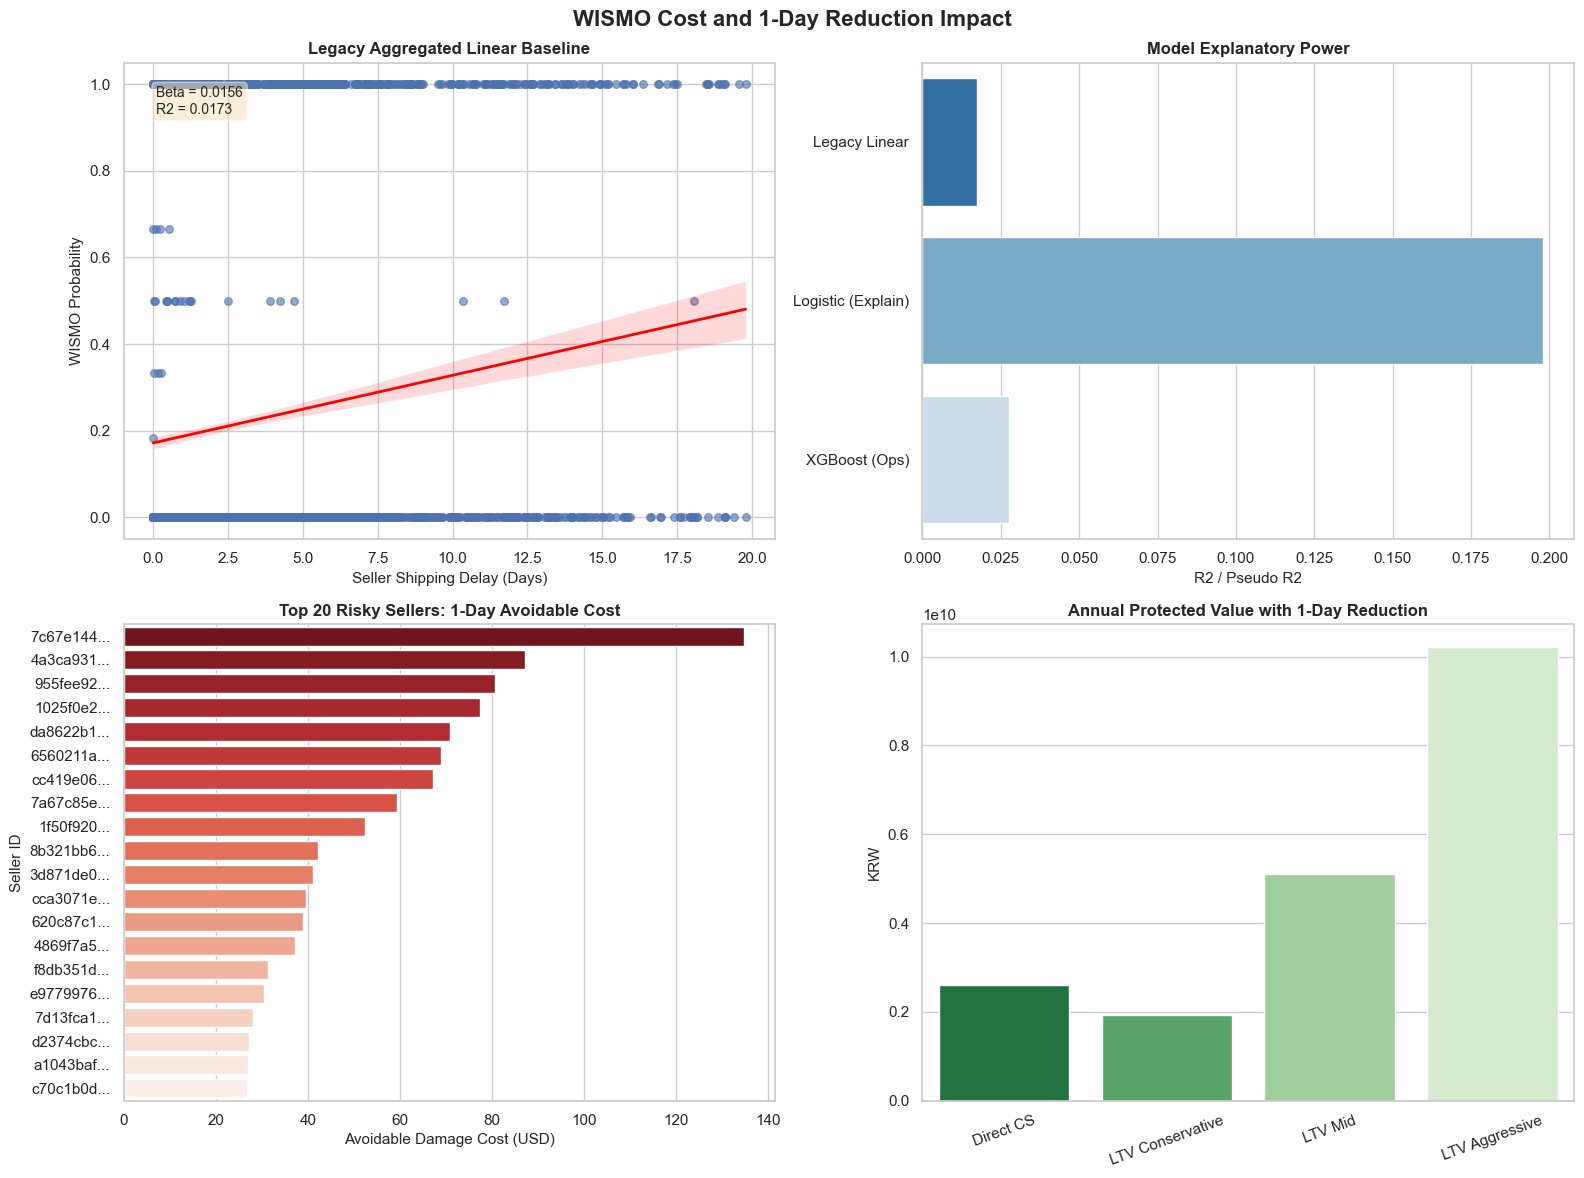

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('WISMO Cost and 1-Day Reduction Impact', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
sns.regplot(
    x='delay_days',
    y='is_wismo',
    data=reg_data,
    scatter_kws={'s': 30, 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=ax1,
)
ax1.set_title('Legacy Aggregated Linear Baseline', fontsize=12, fontweight='bold')
ax1.set_xlabel('Seller Shipping Delay (Days)', fontsize=11)
ax1.set_ylabel('WISMO Probability', fontsize=11)
ax1.text(0.05, 0.95, f'Beta = {legacy_beta:.4f}\nR2 = {legacy_r_squared:.4f}', transform=ax1.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax2 = axes[0, 1]
comparison_df = pd.DataFrame({
    'model': ['Legacy Linear', 'Logistic (Explain)', 'XGBoost (Ops)'],
    'score': [legacy_r_squared, explain_metrics['pseudo_r2'], ops_metrics['pseudo_r2']],
})
sns.barplot(data=comparison_df, x='score', y='model', palette='Blues_r', ax=ax2)
ax2.set_title('Model Explanatory Power', fontsize=12, fontweight='bold')
ax2.set_xlabel('R2 / Pseudo R2', fontsize=11)
ax2.set_ylabel('')

ax3 = axes[1, 0]
top20 = seller_damage_df.head(20)
sns.barplot(data=top20, x='avoidable_damage_cost_usd_1day', y=top20['seller_id'].str[:8] + '...', palette='Reds_r', ax=ax3)
ax3.set_title('Top 20 Risky Sellers: 1-Day Avoidable Cost', fontsize=12, fontweight='bold')
ax3.set_xlabel('Avoidable Damage Cost (USD)', fontsize=11)
ax3.set_ylabel('Seller ID', fontsize=11)

ax4 = axes[1, 1]
annual_value_df = pd.DataFrame({
    'scenario': ['Direct CS', 'LTV Conservative', 'LTV Mid', 'LTV Aggressive'],
    'krw': [savings_krw, ltv_scenarios['conservative'], ltv_scenarios['mid'], ltv_scenarios['aggressive']],
})
sns.barplot(data=annual_value_df, x='scenario', y='krw', palette='Greens_r', ax=ax4)
ax4.set_title('Annual Protected Value with 1-Day Reduction', fontsize=12, fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('KRW', fontsize=11)
ax4.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
